# Sentiment Analysis

Load processed comments with preprocessed text variants from the preprocessing notebook.

In [67]:
import json
from pathlib import Path
from collections import Counter
import nltk
import matplotlib.pyplot as plt
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_VIDEO_DATA_PATH = DATA_DIR / "video_data_processed.json"

try:
    nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    nltk.download("vader_lexicon", quiet=True)


In [68]:

with open(PROCESSED_VIDEO_DATA_PATH, "r", encoding="utf-8") as f:
    processed_video_data = json.load(f)

processed_comments = processed_video_data["comments"]
print(f"Loaded {len(processed_comments)} processed comments\n")

Loaded 46939 processed comments



In [79]:
VADER_TEXT_FIELD = "comment_text_sentiment_analysis"
TOTAL_EXAMPLES = 10

print("SENTIMENT ANALYSIS TEXT EXAMPLES")
print("=" * 80)
processed_data = processed_comments
for comment in processed_comments[:TOTAL_EXAMPLES]:
    print(f"\nID: {comment.get('comment_id')}")
    print(f"Original: {comment.get('comment_text')}")
    print(f"For VADER: {comment.get(VADER_TEXT_FIELD)}")


SENTIMENT ANALYSIS TEXT EXAMPLES

ID: Ugx4TmtthtmdHtePwqV4AaABAg
Original: The whole thing is so phoney STIFF UNNATURAL SMILES..some.unimaginative outfits...so pretenscious all this money spent could have fed the world!..
For VADER: The whole thing is so phoney STIFF UNNATURAL SMILES..some.unimaginative outfits...so pretenscious all this money spent could have fed the world!..

ID: Ugylw87AQ2Q4CkseUkt4AaABAg
Original: Free the CHILDREN
For VADER: Free the CHILDREN

ID: UgxGdNOPXiLmPW4AD4R4AaABAg
Original: Thank you so much 🎉🎉🎉🎉🎉🎉🎉🎉🎉❤❤❤❤❤❤
For VADER: Thank you so much 🎉🎉🎉🎉🎉🎉🎉🎉🎉❤❤❤❤❤❤

ID: Ugz8mOUwbqV8xANIC-F4AaABAg
Original: Thanks, it's an extraordinary event with so many amazing gowns. ❤❤❤
For VADER: Thanks, it's an extraordinary event with so many amazing gowns. ❤❤❤

ID: UgyQpepxkSysJf72hn94AaABAg
Original: Why that song?
For VADER: Why that song?

ID: UgwuNhzfeMcNr7V5liF4AaABAg
Original: When the Queen, Beyoncé showed up, the crowd went crazy! ❤❤❤❤❤❤❤❤❤❤
For VADER: When the Queen, B

In [80]:
VADER_POSITIVE_THRESHOLD = 0.05
VADER_NEGATIVE_THRESHOLD = -0.05

def label_vader_sentiment(compound_score):
    if compound_score >= VADER_POSITIVE_THRESHOLD:
        return "positive"
    if compound_score <= VADER_NEGATIVE_THRESHOLD:
        return "negative"
    return "neutral"

def vader_sentiment_analysis(processed_data):
    """
    Use VADER lexicon for sentiment analysis on processed YouTube comment data.

    @param processed_data: list of dicts with comment text and published date keys
    @returns: list of VADER sentiment result dicts, aligned to processed_data order
    """
    sent_analyser = SentimentIntensityAnalyzer()
    sentiment_results = []

    for entry in processed_data:
        vader_text = entry[VADER_TEXT_FIELD]
        post_date = entry.get("comment_published_at", None)
        scores = sent_analyser.polarity_scores(vader_text)
        compound_score = scores["compound"]

        sentiment_results.append({
            "comment_id": entry.get("comment_id"),
            "published_at": pd.to_datetime(post_date),
            "compound": compound_score,
            "vader_sentiment": label_vader_sentiment(compound_score),
        })
    return sentiment_results

# Run VADER analysis
vader_sentiment = vader_sentiment_analysis(processed_data)
vader_series = pd.Series(result["compound"] for result in vader_sentiment)


In [71]:

# Attach only the VADER sentiment label to each processed row
for row, result in zip(processed_data, vader_sentiment):
    row["vader_sentiment"] = result["vader_sentiment"]

vader_sentiment_by_comment_id = {}
for result in vader_sentiment:
    vader_sentiment_by_comment_id.setdefault(result["comment_id"], []).append(result["vader_sentiment"])


In [72]:

vader_sentiment_counter = Counter(row["vader_sentiment"] for row in processed_data)

print("VADER SENTIMENT SUMMARY")
print("=" * 80)
print(f"Analysed comments: {len(vader_sentiment)}")
for label, count in vader_sentiment_counter.most_common():
    pct = 100 * count / len(processed_data)
    print(f"{label}: {count:,} ({pct:.2f}%)")


VADER SENTIMENT SUMMARY
Analysed comments: 46939
positive: 21,807 (46.46%)
neutral: 14,352 (30.58%)
negative: 10,780 (22.97%)


In [88]:
SENTIMENT_ORDER = ["negative", "neutral", "positive"]
SENTIMENT_COLORS = {
    "positive": "#32cd32",    # lime
    "neutral": "#bdbdbd",     # light grey
    "negative": "#ff6347",    # tomato
}
SENTIMENT_FREE_COLOR = "magenta"

## 1. Sentiment Distribution

Baseline count of positive, neutral, and negative VADER labels.

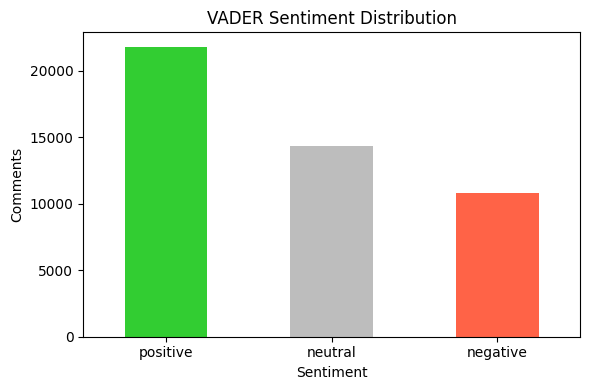

In [82]:
# Sentiment dataframe
sentiment_df = pd.DataFrame(processed_data).copy()

# Convert comment_published_at to datetime with error handling
sentiment_df["comment_published_at"] = pd.to_datetime(sentiment_df["comment_published_at"], errors="coerce")

# Count how many comments fall into each VADER sentiment category
sentiment_counts = sentiment_df["vader_sentiment"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax = sentiment_counts.plot(
    kind="bar",
    ax=ax,
    color=[SENTIMENT_COLORS[label] for label in sentiment_counts.index],
    rot=0,
    title="VADER Sentiment Distribution",
)
ax.set_xlabel("Sentiment")
ax.set_ylabel("Comments")
plt.tight_layout()


## 2. Sentiment Over Time

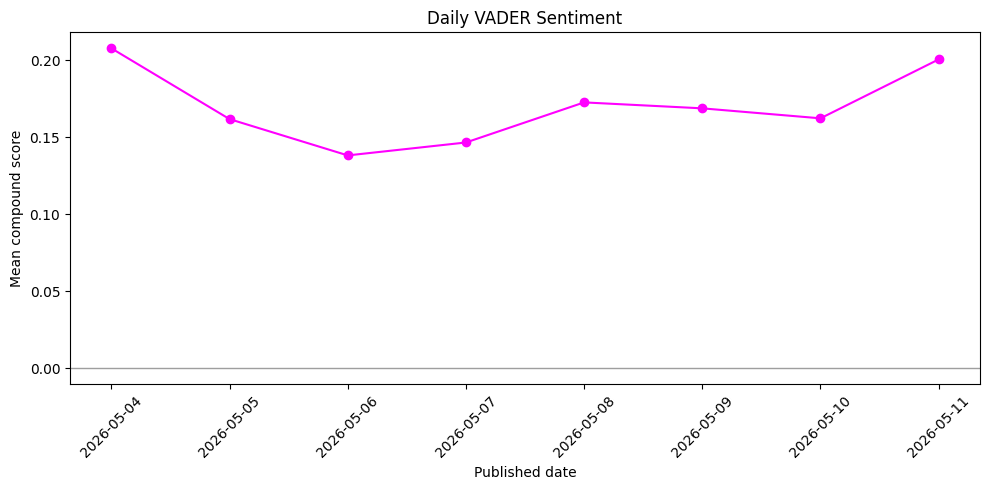

In [90]:
vader_sentiment_df = pd.DataFrame(vader_sentiment).dropna(subset=["published_at"]).copy()
vader_sentiment_df["published_date"] = pd.to_datetime(vader_sentiment_df["published_at"]).dt.date

daily_sentiment = vader_sentiment_df.groupby("published_date")["compound"].mean().reset_index(name="mean_compound")
daily_sentiment["published_date"] = daily_sentiment["published_date"].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(daily_sentiment["published_date"], daily_sentiment["mean_compound"], marker="o", color=SENTIMENT_FREE_COLOR)
ax.set_title("Daily VADER Sentiment")
ax.set_xlabel("Published date")
ax.set_ylabel("Mean compound score")
ax.axhline(0, color="#9e9e9e", linewidth=1)
ax.tick_params(axis="x", labelrotation=45)
plt.tight_layout()


## 3. Sentiment by Entity

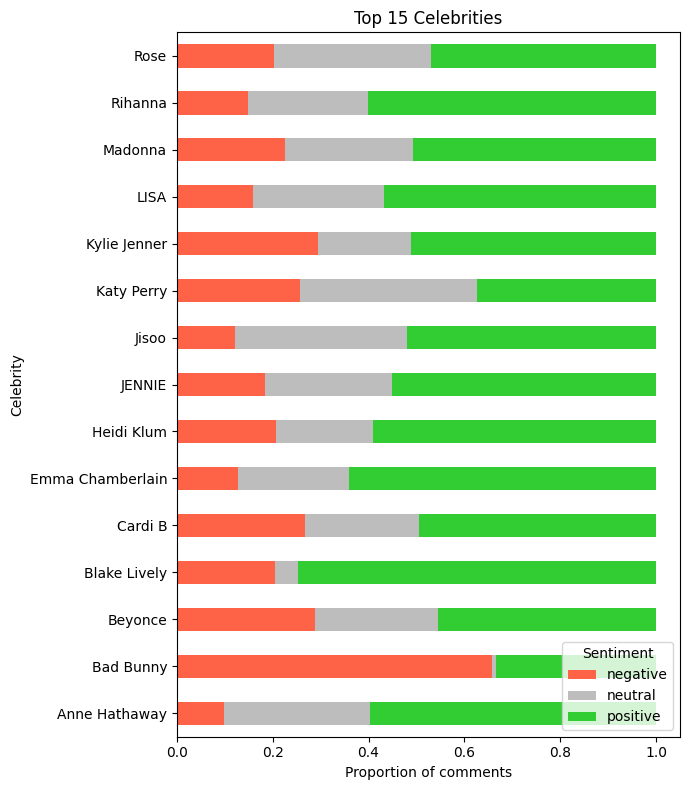

In [92]:

TOP_CELEB_COUNT = 15

celeb_rows = sentiment_df.explode("celebs").dropna(subset=["celebs"])
top_celebs = celeb_rows["celebs"].value_counts().head(TOP_CELEB_COUNT).index
celeb_sentiment = (
    celeb_rows[celeb_rows["celebs"].isin(top_celebs)]
    .groupby(["celebs", "vader_sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SENTIMENT_ORDER, fill_value=0)
)
celeb_sentiment_share = celeb_sentiment.div(celeb_sentiment.sum(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(7, 8))
celeb_sentiment_share.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=[SENTIMENT_COLORS[label] for label in celeb_sentiment_share.columns],
    title=f"Top {TOP_CELEB_COUNT} Celebrities",
)
ax.set_xlabel("Proportion of comments")
ax.set_ylabel("Celebrity")
ax.legend(title="Sentiment", loc="lower right")
plt.tight_layout()
plt.show()



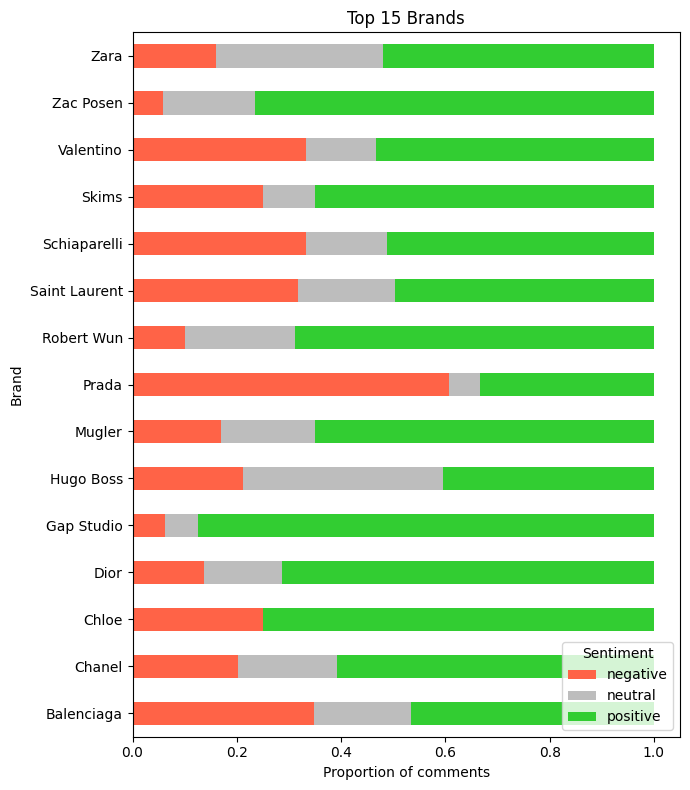

In [93]:

TOP_BRAND_COUNT = 15
brand_rows = sentiment_df.explode("brands").dropna(subset=["brands"])
top_brands = brand_rows["brands"].value_counts().head(TOP_BRAND_COUNT).index
brand_sentiment = (
    brand_rows[brand_rows["brands"].isin(top_brands)]
    .groupby(["brands", "vader_sentiment"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SENTIMENT_ORDER, fill_value=0)
)
brand_sentiment_share = brand_sentiment.div(brand_sentiment.sum(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(7, 8))
brand_sentiment_share.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=[SENTIMENT_COLORS[label] for label in brand_sentiment_share.columns],
    title=f"Top {TOP_BRAND_COUNT} Brands",
)
ax.set_xlabel("Proportion of comments")
ax.set_ylabel("Brand")
ax.legend(title="Sentiment", loc="lower right")
plt.tight_layout()
plt.show()


## 5. Entity Mention Frequency

Most-mentioned celebrities and brands, used as context for interpreting entity sentiment.

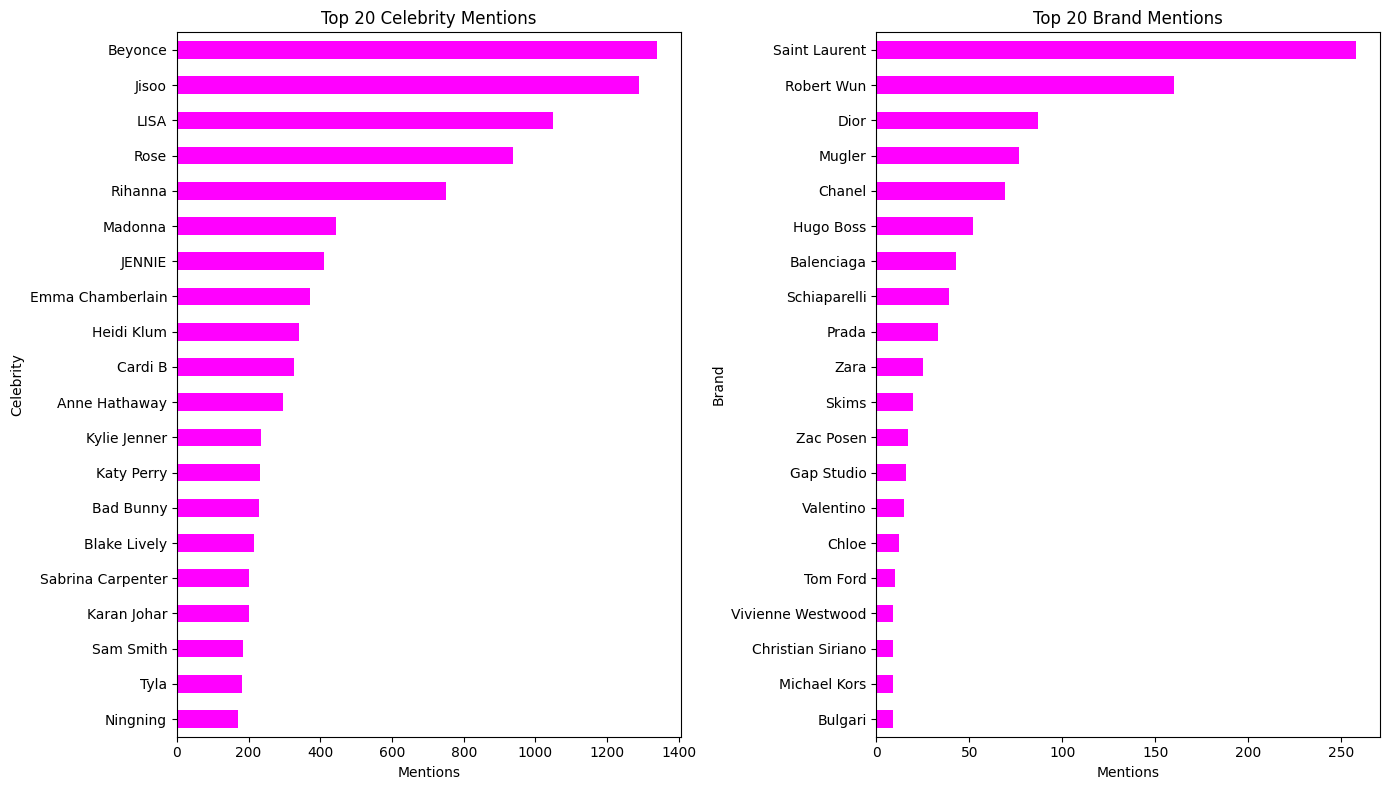

In [ ]:
from tkinter.constants import SE


TOP_MENTION_COUNT = 20
celeb_counts = celeb_rows["celebs"].value_counts().head(TOP_MENTION_COUNT).sort_values()
brand_counts = brand_rows["brands"].value_counts().head(TOP_MENTION_COUNT).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
celeb_counts.plot(
    kind="barh",
    ax=axes[0],
    color=SENTIMENT_FREE_COLOR,
    title=f"Top {TOP_MENTION_COUNT} Celebrity Mentions",
)
brand_counts.plot(
    kind="barh",
    ax=axes[1],
    color=SENTIMENT_FREE_COLOR,
    title=f"Top {TOP_MENTION_COUNT} Brand Mentions",
)
axes[0].set_xlabel("Mentions")
axes[0].set_ylabel("Celebrity")
axes[1].set_xlabel("Mentions")
axes[1].set_ylabel("Brand")
plt.tight_layout()
